In [1]:
import os
import json
from typing import Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
FIG_SIZE2 =(10, 4.5)
FIG_SIZE3 =(7.5, 5.2)

In [3]:
def plot_base_vs_rlvr_pretty(
    base_summary_path: str,
    rlvr_summary_path: str,
    out_prefix: str,
    *,
    base_label: str = "Base",
    rlvr_label: str = "RL",
    dpi: int = 300,
    save_pdf: bool = True,
) -> Dict[str, str]:
    # ---------- helpers ----------
    def _load(path: str) -> dict:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    def _to_float_list(arr):
        return [np.nan if x is None else float(x) for x in arr]

    def _min_len(*seqs) -> int:
        seqs = [s for s in seqs if s is not None]
        return min(len(s) for s in seqs) if seqs else 0

    def _pow2_ticks(upto: int):
        ticks = [1]
        v = 2
        while v <= max(1, upto):
            ticks.append(v)
            v *= 2
        return ticks

    def _set_log2_axis(ax, K: int):
        ticks = _pow2_ticks(K)
        try:
            ax.set_xscale("log", base=2)
        except TypeError:
            ax.set_xscale("log", basex=2)
        ax.set_xlim(1, ticks[-1])
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        return ticks

    def _boxify(ax):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.1)
        ax.grid(True, which="major", alpha=0.25)
        ax.margins(x=0.02)

    # ---------- load ----------
    base = _load(base_summary_path)
    rlvr = _load(rlvr_summary_path)
    task = (base.get("task") or "activity").capitalize()
    if task == 'Lis':
        task = 'LIS'

    # ---------- curves (Answer) ----------
    b_pass_ans = _to_float_list(base.get("passk_answer_curve", []))
    b_sc_ans   = _to_float_list(base.get("sc_answer_curve", []))
    r_pass_ans = _to_float_list(rlvr.get("passk_answer_curve", []))
    r_sc_ans   = _to_float_list(rlvr.get("sc_answer_curve", []))
    K_ans = _min_len(b_pass_ans, b_sc_ans, r_pass_ans, r_sc_ans)
    x_ans = list(range(1, K_ans + 1))

    # ---------- curves (IDs) ----------
    b_pass_ids = _to_float_list(base.get("passk_ids_curve", []))
    b_sc_ids   = _to_float_list(base.get("sc_ids_curve", []))
    r_pass_ids = _to_float_list(rlvr.get("passk_ids_curve", []))
    r_sc_ids   = _to_float_list(rlvr.get("sc_ids_curve", []))
    K_ids = _min_len(b_pass_ids, b_sc_ids, r_pass_ids, r_sc_ids)
    x_ids = list(range(1, K_ids + 1))

    # ---------- styling ----------
    sns.set_theme(style="ticks", context="talk")
    COLORS = {
        "base_pass": "#1f77b4",  # blue
        "rl_pass":   "#e15759",  # coral/red
        "base_sc":   "#2ca02c",  # green
        "rl_sc":     "#9467bd",  # purple
    }
    MARKERS = {"base_pass": "^", "rl_pass": "v", "base_sc": "s", "rl_sc": "D"}
    LSTYLES = {"pass": "-", "sc": "--"}
    LW = 2.2
    MS = 6.0

    fig, (axL, axR) = plt.subplots(1, 2, figsize=FIG_SIZE2)  # separate axes

    # ---------- LEFT subplot: Answer ----------
    handles = []
    labels  = []

    if K_ans > 0:
        ticks_ans = _set_log2_axis(axL, K_ans)
        mark_idx_ans = [t - 1 for t in ticks_ans if 1 <= t <= K_ans]

        h1 = axL.plot(x_ans, b_pass_ans[:K_ans],
                      color=COLORS["base_pass"], ls=LSTYLES["pass"], marker=MARKERS["base_pass"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{base_label} — Pass@k")[0]
        h2 = axL.plot(x_ans, r_pass_ans[:K_ans],
                      color=COLORS["rl_pass"], ls=LSTYLES["pass"], marker=MARKERS["rl_pass"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{rlvr_label} — Pass@k")[0]
        h3 = axL.plot(x_ans, b_sc_ans[:K_ans],
                      color=COLORS["base_sc"], ls=LSTYLES["sc"], marker=MARKERS["base_sc"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{base_label} — SC@k")[0]
        h4 = axL.plot(x_ans, r_sc_ans[:K_ans],
                      color=COLORS["rl_sc"], ls=LSTYLES["sc"], marker=MARKERS["rl_sc"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{rlvr_label} — SC@k")[0]

        handles = [h1, h2, h3, h4]
        labels  = [h.get_label() for h in handles]

    axL.set_title(f"{task} — Answer Accuracy vs k")
    axL.set_xlabel("$k$")
    axL.set_ylabel("Accuracy")
    # axL.set_ylim(0.0, 1.0)
    _boxify(axL)

    # ---------- RIGHT subplot: IDs ----------
    if K_ids > 0:
        ticks_ids = _set_log2_axis(axR, K_ids)
        mark_idx_ids = [t - 1 for t in ticks_ids if 1 <= t <= K_ids]

        axR.plot(x_ids, b_pass_ids[:K_ids],
                 color=COLORS["base_pass"], ls=LSTYLES["pass"], marker=MARKERS["base_pass"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        axR.plot(x_ids, r_pass_ids[:K_ids],
                 color=COLORS["rl_pass"], ls=LSTYLES["pass"], marker=MARKERS["rl_pass"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        axR.plot(x_ids, b_sc_ids[:K_ids],
                 color=COLORS["base_sc"], ls=LSTYLES["sc"], marker=MARKERS["base_sc"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        axR.plot(x_ids, r_sc_ids[:K_ids],
                 color=COLORS["rl_sc"], ls=LSTYLES["sc"], marker=MARKERS["rl_sc"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)

    axR.set_title(f"{task} — IDs Accuracy vs k")
    axR.set_xlabel("$k$")
    axR.set_ylabel("Accuracy")
    # axR.set_ylim(0.0, 1.0)
    _boxify(axR)

    # ---------- ONE legend for all four lines (from left subplot handles) ----------
    if handles:
        fig.legend(handles, labels, loc="lower center",
                   ncol=4, frameon=True, columnspacing=1.4, handlelength=2.6)
        plt.tight_layout(rect=[0.02, 0.12, 0.98, 0.98])  # room for legend
    else:
        plt.tight_layout()

    # ---------- save ----------
    os.makedirs(os.path.dirname(out_prefix) or ".", exist_ok=True)
    out_png = f"{out_prefix}.png"
    out_pdf = f"{out_prefix}.pdf" if save_pdf else ""
    fig.savefig(out_png, dpi=dpi)
    if save_pdf:
        fig.savefig(out_pdf)
    plt.close(fig)
    return {"png": out_png, "pdf": out_pdf}



In [4]:
def plot_three_runs_pretty(
    a_summary_path: str,
    b_summary_path: str,
    c_summary_path: str,
    out_prefix: str,
    *,
    a_label: str = "A",
    b_label: str = "B",
    c_label: str = "C",
    dpi: int = 300,
    save_pdf: bool = True,
) -> Dict[str, str]:
    """
    Plot Pass@k and Self-Consistency (SC@k) for three runs (A/B/C).
    Left: Answer curves; Right: IDs curves.
    Legend at bottom (2 rows x 3 columns): [A Pass, B Pass, C Pass, A SC, B SC, C SC].
    """
    import os, json
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ---------- helpers ----------
    def _load(path: str) -> dict:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    def _to_float_list(arr):
        return [np.nan if x is None else float(x) for x in (arr or [])]

    def _min_len(*seqs) -> int:
        seqs = [s for s in seqs if s is not None and len(s) > 0]
        return min(len(s) for s in seqs) if seqs else 0

    def _pow2_ticks(upto: int):
        ticks = [1]
        v = 2
        while v <= max(1, upto):
            ticks.append(v)
            v *= 2
        return ticks

    def _set_log2_axis(ax, K: int):
        ticks = _pow2_ticks(K)
        try:
            ax.set_xscale("log", base=2)
        except TypeError:
            ax.set_xscale("log", basex=2)
        ax.set_xlim(1, ticks[-1])
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        return ticks

    def _boxify(ax):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.1)
        ax.grid(True, which="major", alpha=0.25)
        ax.margins(x=0.02)

    # ---------- load ----------
    A = _load(a_summary_path)
    B = _load(b_summary_path)
    C = _load(c_summary_path)

    task = (A.get("task") or "activity").capitalize()
    if task == "Lis":
        task = "LIS"

    # ---------- curves (Answer) ----------
    a_pass_ans = _to_float_list(A.get("passk_answer_curve"))
    a_sc_ans   = _to_float_list(A.get("sc_answer_curve"))
    b_pass_ans = _to_float_list(B.get("passk_answer_curve"))
    b_sc_ans   = _to_float_list(B.get("sc_answer_curve"))
    c_pass_ans = _to_float_list(C.get("passk_answer_curve"))
    c_sc_ans   = _to_float_list(C.get("sc_answer_curve"))
    K_ans = _min_len(a_pass_ans, a_sc_ans, b_pass_ans, b_sc_ans, c_pass_ans, c_sc_ans)
    x_ans = list(range(1, K_ans + 1))

    # ---------- curves (IDs) ----------
    a_pass_ids = _to_float_list(A.get("passk_ids_curve"))
    a_sc_ids   = _to_float_list(A.get("sc_ids_curve"))
    b_pass_ids = _to_float_list(B.get("passk_ids_curve"))
    b_sc_ids   = _to_float_list(B.get("sc_ids_curve"))
    c_pass_ids = _to_float_list(C.get("passk_ids_curve"))
    c_sc_ids   = _to_float_list(C.get("sc_ids_curve"))
    K_ids = _min_len(a_pass_ids, a_sc_ids, b_pass_ids, b_sc_ids, c_pass_ids, c_sc_ids)
    x_ids = list(range(1, K_ids + 1))

    # ---------- styling ----------
    sns.set_theme(style="ticks", context="talk")
    # One color per RUN; linestyle encodes metric (Pass solid, SC dashed)
    COLORS = {"A": "#1f77b4",  # blue
              "B": "#e15759",  # coral/red
              "C": "#9467bd"}  # purple
    MARKERS_PASS = {"A": "^", "B": "v", "C": "o"}
    MARKERS_SC   = {"A": "s", "B": "D", "C": "P"}
    LSTYLES = {"pass": "-", "sc": "--"}
    LW = 2.2
    MS = 6.0

    fig, (axL, axR) = plt.subplots(1, 2, figsize=FIG_SIZE2)  # separate axes

    # ---------- LEFT subplot: Answer ----------
    handles = []
    labels  = []
    if K_ans > 0:
        ticks_ans = _set_log2_axis(axL, K_ans)
        mark_idx_ans = [t - 1 for t in ticks_ans if 1 <= t <= K_ans]

        # A
        hA_pass = axL.plot(x_ans, a_pass_ans[:K_ans],
                           color=COLORS["A"], ls=LSTYLES["pass"], marker=MARKERS_PASS["A"],
                           lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{a_label} — Pass@k")[0]
        hA_sc   = axL.plot(x_ans, a_sc_ans[:K_ans],
                           color=COLORS["A"], ls=LSTYLES["sc"], marker=MARKERS_SC["A"],
                           lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{a_label} — SC@k")[0]
        # B
        hB_pass = axL.plot(x_ans, b_pass_ans[:K_ans],
                           color=COLORS["B"], ls=LSTYLES["pass"], marker=MARKERS_PASS["B"],
                           lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{b_label} — Pass@k")[0]
        hB_sc   = axL.plot(x_ans, b_sc_ans[:K_ans],
                           color=COLORS["B"], ls=LSTYLES["sc"], marker=MARKERS_SC["B"],
                           lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{b_label} — SC@k")[0]
        # C
        hC_pass = axL.plot(x_ans, c_pass_ans[:K_ans],
                           color=COLORS["C"], ls=LSTYLES["pass"], marker=MARKERS_PASS["C"],
                           lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{c_label} — Pass@k")[0]
        hC_sc   = axL.plot(x_ans, c_sc_ans[:K_ans],
                           color=COLORS["C"], ls=LSTYLES["sc"], marker=MARKERS_SC["C"],
                           lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{c_label} — SC@k")[0]

        # Arrange legend entries so 1st row = Pass, 2nd row = SC
        handles = [hA_pass, hB_pass, hC_pass, hA_sc, hB_sc, hC_sc]
        labels  = [h.get_label() for h in handles]

    axL.set_title(f"{task} — Answer Accuracy vs k")
    axL.set_xlabel("$k$")
    axL.set_ylabel("Accuracy")
    _boxify(axL)

    # ---------- RIGHT subplot: IDs ----------
    if K_ids > 0:
        ticks_ids = _set_log2_axis(axR, K_ids)
        mark_idx_ids = [t - 1 for t in ticks_ids if 1 <= t <= K_ids]

        # A
        axR.plot(x_ids, a_pass_ids[:K_ids],
                 color=COLORS["A"], ls=LSTYLES["pass"], marker=MARKERS_PASS["A"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        axR.plot(x_ids, a_sc_ids[:K_ids],
                 color=COLORS["A"], ls=LSTYLES["sc"], marker=MARKERS_SC["A"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        # B
        axR.plot(x_ids, b_pass_ids[:K_ids],
                 color=COLORS["B"], ls=LSTYLES["pass"], marker=MARKERS_PASS["B"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        axR.plot(x_ids, b_sc_ids[:K_ids],
                 color=COLORS["B"], ls=LSTYLES["sc"], marker=MARKERS_SC["B"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        # C
        axR.plot(x_ids, c_pass_ids[:K_ids],
                 color=COLORS["C"], ls=LSTYLES["pass"], marker=MARKERS_PASS["C"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        axR.plot(x_ids, c_sc_ids[:K_ids],
                 color=COLORS["C"], ls=LSTYLES["sc"], marker=MARKERS_SC["C"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)

    axR.set_title(f"{task} — IDs Accuracy vs k")
    axR.set_xlabel("$k$")
    axR.set_ylabel("Accuracy")
    _boxify(axR)

    # ---------- Legend (bottom, 2 rows x 3 columns) ----------
    if handles:
        fig.legend(handles, labels, loc="lower center",
                   ncol=6, frameon=True, columnspacing=1.6, handlelength=2.6)
        plt.tight_layout(rect=[0.02, 0.20, 0.98, 0.98])  # extra room for 2-row legend
    else:
        plt.tight_layout()

    # ---------- save ----------
    os.makedirs(os.path.dirname(out_prefix) or ".", exist_ok=True)
    out_png = f"{out_prefix}.png"
    out_pdf = f"{out_prefix}.pdf" if save_pdf else ""
    fig.savefig(out_png, dpi=dpi)
    if save_pdf:
        fig.savefig(out_pdf)
    plt.close(fig)
    return {"png": out_png, "pdf": out_pdf}


In [25]:
# ---------------- example usage ----------------
paths = plot_base_vs_rlvr_pretty(
    base_summary_path="passk_out/activity_Qwen2.5-7B-Instruct_metrics_summary.json",
    rlvr_summary_path="passk_out/activity_activity_answer_qwen7b_metrics_summary.json",
    out_prefix="figs4page/activity_base_rlvr",
    base_label="Base",
    rlvr_label="RL $(r_{ans})$"
)
print(paths)


{'png': 'figs4page/activity_base_rlvr.png', 'pdf': 'figs4page/activity_base_rlvr.pdf'}


In [28]:
# ---------------- example usage ----------------
paths = plot_three_runs_pretty(
    a_summary_path="passk_out/lis_Qwen2.5-7B-Instruct_metrics_summary.json",
    b_summary_path="passk_out/lis_lis_answer_qwen7b_metrics_summary.json",
    c_summary_path="passk_out/lis_lis_answer_reason_metrics_summary.json",
    out_prefix="figs4page/lis_base_rlvr",
    a_label = "Base",
    b_label = "RL $(r_{ans})$",
    c_label = "RL $(r_{ans+fmt})$"
)
print(paths)


{'png': 'figs4page/lis_base_rlvr.png', 'pdf': 'figs4page/lis_base_rlvr.pdf'}


In [7]:
def plot_four_panels_row_pretty(
    *,
    base_summary_path: str,
    rlvr_summary_path: str,
    a_summary_path: str,
    b_summary_path: str,
    c_summary_path: str,
    out_prefix: str,
    base_label: str = "Base",
    rlvr_label: str = "RL",
    a_label: str = "A",
    b_label: str = "B",
    c_label: str = "C",
    dpi: int = 300,
    save_pdf: bool = True,
) -> Dict[str, str]:
    """
    Combine the two 2-panel figures into one 1x4 row:
      [ Base vs RL (Answer) | Base vs RL (IDs) | 3-Runs (Answer) | 3-Runs (IDs) ]
    - One legend centered below (2 rows).
    - Only the leftmost subplot shows the y-axis label.
    - Axes use log2 x-scale like your originals.
    """
    import os, json, math
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ---------------- helpers ----------------
    def _load(path: str) -> dict:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    def _to_float_list(arr):
        return [np.nan if x is None else float(x) for x in (arr or [])]

    def _min_len(*seqs) -> int:
        seqs = [s for s in seqs if s is not None and len(s) > 0]
        return min(len(s) for s in seqs) if seqs else 0

    def _pow2_ticks(upto: int):
        ticks = [1]
        v = 2
        while v <= max(1, upto):
            ticks.append(v)
            v *= 2
        return ticks

    def _set_log2_axis(ax, K: int):
        ticks = _pow2_ticks(K)
        try:
            ax.set_xscale("log", base=2)
        except TypeError:  # older Matplotlib
            ax.set_xscale("log", basex=2)
        ax.set_xlim(1, ticks[-1])
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        return ticks

    def _boxify(ax):
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_linewidth(1.1)
        ax.grid(True, which="major", alpha=0.25)
        ax.margins(x=0.02)

    # consistent styling
    sns.set_theme(style="ticks", context="talk")

    # colors/markers matching your originals
    COLORS_PAIR = {
        "base_pass": "#1f77b4",  # blue
        "rl_pass":   "#e15759",  # coral/red
        "base_sc":   "#2ca02c",  # green
        "rl_sc":     "#9467bd",  # purple
    }
    MARKERS_PAIR = {"base_pass": "^", "rl_pass": "v", "base_sc": "s", "rl_sc": "D"}

    COLORS_TRIPLE = {"A": "#1f77b4", "B": "#e15759", "C": "#9467bd"}  # blue/red/purple
    MARKERS_PASS = {"A": "^", "B": "v", "C": "o"}
    MARKERS_SC   = {"A": "s", "B": "D", "C": "P"}
    LSTYLES = {"pass": "-", "sc": "--"}
    LW = 2.2
    MS = 6.0

    # ---------------- load data ----------------
    base = _load(base_summary_path)
    rlvr = _load(rlvr_summary_path)
    A = _load(a_summary_path)
    B = _load(b_summary_path)
    C = _load(c_summary_path)

    task_pair = (base.get("task") or "activity").capitalize()
    if task_pair == "Lis":
        task_pair = "LIS"
    task_trip = (A.get("task") or "activity").capitalize()
    if task_trip == "Lis":
        task_trip = "LIS"

    # ---------------- figure ----------------
    FIGSIZE = (16, 4.8)  # wide row of four
    fig, axes = plt.subplots(1, 4, figsize=FIGSIZE, sharey=True)
    ax0, ax1, ax2, ax3 = axes

    legend_handles = []
    legend_labels = []

    # ---------- left pair: Base vs RL (Answer, IDs) ----------
    # Answer curves
    b_pass_ans = _to_float_list(base.get("passk_answer_curve"))
    b_sc_ans   = _to_float_list(base.get("sc_answer_curve"))
    r_pass_ans = _to_float_list(rlvr.get("passk_answer_curve"))
    r_sc_ans   = _to_float_list(rlvr.get("sc_answer_curve"))
    K_ans_pair = _min_len(b_pass_ans, b_sc_ans, r_pass_ans, r_sc_ans)
    if K_ans_pair > 0:
        x_ans = list(range(1, K_ans_pair + 1))
        ticks_ans = _set_log2_axis(ax0, K_ans_pair)
        mark_idx_ans = [t - 1 for t in ticks_ans if 1 <= t <= K_ans_pair]

        h1 = ax0.plot(x_ans, b_pass_ans[:K_ans_pair],
                      color=COLORS_PAIR["base_pass"], ls=LSTYLES["pass"], marker=MARKERS_PAIR["base_pass"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{base_label} — Pass@k")[0]
        h2 = ax0.plot(x_ans, r_pass_ans[:K_ans_pair],
                      color=COLORS_PAIR["rl_pass"], ls=LSTYLES["pass"], marker=MARKERS_PAIR["rl_pass"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{rlvr_label} — Pass@k")[0]
        h3 = ax0.plot(x_ans, b_sc_ans[:K_ans_pair],
                      color=COLORS_PAIR["base_sc"], ls=LSTYLES["sc"], marker=MARKERS_PAIR["base_sc"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{base_label} — SC@k")[0]
        h4 = ax0.plot(x_ans, r_sc_ans[:K_ans_pair],
                      color=COLORS_PAIR["rl_sc"], ls=LSTYLES["sc"], marker=MARKERS_PAIR["rl_sc"],
                      lw=LW, ms=MS, markevery=mark_idx_ans, label=f"{rlvr_label} — SC@k")[0]

        legend_handles += [h1, h2, h3, h4]
        legend_labels  += [h.get_label() for h in [h1, h2, h3, h4]]

    ax0.set_title(f"{task_pair} — Answer Accuracy vs k")
    ax0.set_xlabel("$k$")
    ax0.set_ylabel("Accuracy")  # only this one has the y-label
    _boxify(ax0)

    # IDs curves
    b_pass_ids = _to_float_list(base.get("passk_ids_curve"))
    b_sc_ids   = _to_float_list(base.get("sc_ids_curve"))
    r_pass_ids = _to_float_list(rlvr.get("passk_ids_curve"))
    r_sc_ids   = _to_float_list(rlvr.get("sc_ids_curve"))
    K_ids_pair = _min_len(b_pass_ids, b_sc_ids, r_pass_ids, r_sc_ids)
    if K_ids_pair > 0:
        x_ids = list(range(1, K_ids_pair + 1))
        ticks_ids = _set_log2_axis(ax1, K_ids_pair)
        mark_idx_ids = [t - 1 for t in ticks_ids if 1 <= t <= K_ids_pair]

        ax1.plot(x_ids, b_pass_ids[:K_ids_pair],
                 color=COLORS_PAIR["base_pass"], ls=LSTYLES["pass"], marker=MARKERS_PAIR["base_pass"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        ax1.plot(x_ids, r_pass_ids[:K_ids_pair],
                 color=COLORS_PAIR["rl_pass"], ls=LSTYLES["pass"], marker=MARKERS_PAIR["rl_pass"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        ax1.plot(x_ids, b_sc_ids[:K_ids_pair],
                 color=COLORS_PAIR["base_sc"], ls=LSTYLES["sc"], marker=MARKERS_PAIR["base_sc"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)
        ax1.plot(x_ids, r_sc_ids[:K_ids_pair],
                 color=COLORS_PAIR["rl_sc"], ls=LSTYLES["sc"], marker=MARKERS_PAIR["rl_sc"],
                 lw=LW, ms=MS, markevery=mark_idx_ids)

    ax1.set_title(f"{task_pair} — IDs Accuracy vs k")
    ax1.set_xlabel("$k$")
    ax1.set_ylabel(None)  # hide duplicate y-label
    _boxify(ax1)

    # ---------- right pair: 3 runs (Answer, IDs) ----------
    # Answer
    a_pass_ans = _to_float_list(A.get("passk_answer_curve"))
    a_sc_ans   = _to_float_list(A.get("sc_answer_curve"))
    b_pass_ans = _to_float_list(B.get("passk_answer_curve"))
    b_sc_ans   = _to_float_list(B.get("sc_answer_curve"))
    c_pass_ans = _to_float_list(C.get("passk_answer_curve"))
    c_sc_ans   = _to_float_list(C.get("sc_answer_curve"))
    K_ans_trip = _min_len(a_pass_ans, a_sc_ans, b_pass_ans, b_sc_ans, c_pass_ans, c_sc_ans)
    if K_ans_trip > 0:
        x_ans2 = list(range(1, K_ans_trip + 1))
        ticks_ans2 = _set_log2_axis(ax2, K_ans_trip)
        mark_idx_ans2 = [t - 1 for t in ticks_ans2 if 1 <= t <= K_ans_trip]

        hA_pass = ax2.plot(x_ans2, a_pass_ans[:K_ans_trip],
                           color=COLORS_TRIPLE["A"], ls=LSTYLES["pass"], marker=MARKERS_PASS["A"],
                           lw=LW, ms=MS, markevery=mark_idx_ans2, label=f"{a_label} — Pass@k")[0]
        hA_sc   = ax2.plot(x_ans2, a_sc_ans[:K_ans_trip],
                           color=COLORS_TRIPLE["A"], ls=LSTYLES["sc"], marker=MARKERS_SC["A"],
                           lw=LW, ms=MS, markevery=mark_idx_ans2, label=f"{a_label} — SC@k")[0]
        hB_pass = ax2.plot(x_ans2, b_pass_ans[:K_ans_trip],
                           color=COLORS_TRIPLE["B"], ls=LSTYLES["pass"], marker=MARKERS_PASS["B"],
                           lw=LW, ms=MS, markevery=mark_idx_ans2, label=f"{b_label} — Pass@k")[0]
        hB_sc   = ax2.plot(x_ans2, b_sc_ans[:K_ans_trip],
                           color=COLORS_TRIPLE["B"], ls=LSTYLES["sc"], marker=MARKERS_SC["B"],
                           lw=LW, ms=MS, markevery=mark_idx_ans2, label=f"{b_label} — SC@k")[0]
        hC_pass = ax2.plot(x_ans2, c_pass_ans[:K_ans_trip],
                           color=COLORS_TRIPLE["C"], ls=LSTYLES["pass"], marker=MARKERS_PASS["C"],
                           lw=LW, ms=MS, markevery=mark_idx_ans2, label=f"{c_label} — Pass@k")[0]
        hC_sc   = ax2.plot(x_ans2, c_sc_ans[:K_ans_trip],
                           color=COLORS_TRIPLE["C"], ls=LSTYLES["sc"], marker=MARKERS_SC["C"],
                           lw=LW, ms=MS, markevery=mark_idx_ans2, label=f"{c_label} — SC@k")[0]

        legend_handles += [hA_pass, hB_pass, hC_pass, hA_sc, hB_sc, hC_sc]
        legend_labels  += [h.get_label() for h in [hA_pass, hB_pass, hC_pass, hA_sc, hB_sc, hC_sc]]

    ax2.set_title(f"{task_trip} — Answer Accuracy vs k")
    ax2.set_xlabel("$k$")
    ax2.set_ylabel(None)
    _boxify(ax2)

    # IDs
    a_pass_ids = _to_float_list(A.get("passk_ids_curve"))
    a_sc_ids   = _to_float_list(A.get("sc_ids_curve"))
    b_pass_ids = _to_float_list(B.get("passk_ids_curve"))
    b_sc_ids   = _to_float_list(B.get("sc_ids_curve"))
    c_pass_ids = _to_float_list(C.get("passk_ids_curve"))
    c_sc_ids   = _to_float_list(C.get("sc_ids_curve"))
    K_ids_trip = _min_len(a_pass_ids, a_sc_ids, b_pass_ids, b_sc_ids, c_pass_ids, c_sc_ids)
    if K_ids_trip > 0:
        x_ids2 = list(range(1, K_ids_trip + 1))
        ticks_ids2 = _set_log2_axis(ax3, K_ids_trip)
        mark_idx_ids2 = [t - 1 for t in ticks_ids2 if 1 <= t <= K_ids_trip]

        ax3.plot(x_ids2, a_pass_ids[:K_ids_trip],
                 color=COLORS_TRIPLE["A"], ls=LSTYLES["pass"], marker=MARKERS_PASS["A"],
                 lw=LW, ms=MS, markevery=mark_idx_ids2)
        ax3.plot(x_ids2, a_sc_ids[:K_ids_trip],
                 color=COLORS_TRIPLE["A"], ls=LSTYLES["sc"], marker=MARKERS_SC["A"],
                 lw=LW, ms=MS, markevery=mark_idx_ids2)
        ax3.plot(x_ids2, b_pass_ids[:K_ids_trip],
                 color=COLORS_TRIPLE["B"], ls=LSTYLES["pass"], marker=MARKERS_PASS["B"],
                 lw=LW, ms=MS, markevery=mark_idx_ids2)
        ax3.plot(x_ids2, b_sc_ids[:K_ids_trip],
                 color=COLORS_TRIPLE["B"], ls=LSTYLES["sc"], marker=MARKERS_SC["B"],
                 lw=LW, ms=MS, markevery=mark_idx_ids2)
        ax3.plot(x_ids2, c_pass_ids[:K_ids_trip],
                 color=COLORS_TRIPLE["C"], ls=LSTYLES["pass"], marker=MARKERS_PASS["C"],
                 lw=LW, ms=MS, markevery=mark_idx_ids2)
        ax3.plot(x_ids2, c_sc_ids[:K_ids_trip],
                 color=COLORS_TRIPLE["C"], ls=LSTYLES["sc"], marker=MARKERS_SC["C"],
                 lw=LW, ms=MS, markevery=mark_idx_ids2)

    ax3.set_title(f"{task_trip} — IDs Accuracy vs k")
    ax3.set_xlabel("$k$")
    ax3.set_ylabel(None)
    _boxify(ax3)

    # ---------- single legend (2 rows) ----------
    # De-duplicate labels while preserving order
    seen = set()
    uniq_handles, uniq_labels = [], []
    for h, lab in zip(legend_handles, legend_labels):
        if lab not in seen:
            uniq_handles.append(h)
            uniq_labels.append(lab)
            seen.add(lab)

    ncol = max(3, math.ceil(len(uniq_labels) / 2))  # 2 rows
    fig.legend(uniq_handles, uniq_labels, loc="lower center",
               ncol=ncol, frameon=True, columnspacing=1.6, handlelength=2.6)

    plt.tight_layout(rect=[0.02, 0.20, 0.98, 0.98])  # space for the legend

    # ---------- save ----------
    os.makedirs(os.path.dirname(out_prefix) or ".", exist_ok=True)
    out_png = f"{out_prefix}.png"
    out_pdf = f"{out_prefix}.pdf" if save_pdf else ""
    fig.savefig(out_png, dpi=dpi)
    if save_pdf:
        fig.savefig(out_pdf)
    plt.close(fig)
    return {"png": out_png, "pdf": out_pdf}


In [8]:
paths = plot_four_panels_row_pretty(
    base_summary_path="passk_out/activity_Qwen2.5-7B-Instruct_metrics_summary.json",
    rlvr_summary_path="passk_out/activity_activity_answer_qwen7b_metrics_summary.json",
    a_summary_path="passk_out/lis_Qwen2.5-7B-Instruct_metrics_summary.json",
    b_summary_path="passk_out/lis_lis_answer_qwen7b_metrics_summary.json",
    c_summary_path="passk_out/lis_lis_answer_reason_metrics_summary.json",
    out_prefix="figs4page/combined_four_row",
    base_label="Base",
    rlvr_label="RL $(r_{ans})$",
    a_label="Base",
    b_label="RL $(r_{ans})$",
    c_label="RL $(r_{ans+fmt})$",
)
print(paths)


{'png': 'figs4page/combined_four_row.png', 'pdf': 'figs4page/combined_four_row.pdf'}


In [ ]:
paths = plot_four_panels_row_pretty(
    base_summary_path="passk_out/activity_Qwen2.5-7B-Instruct_metrics_summary.json",
    rlvr_summary_path="passk_out/activity_activity_answer_qwen7b_metrics_summary.json",
    a_summary_path="passk_out/lis_Qwen2.5-7B-Instruct_metrics_summary.json",
    b_summary_path="passk_out/lis_lis_answer_qwen7b_metrics_summary.json",
    c_summary_path="passk_out/lis_lis_answer_reason_metrics_summary.json",
    out_prefix="figs4page/combined_four_row",
    base_label="Base",
    rlvr_label="RL $(r_{ans})$",
    a_label="Base",
    b_label="RL $(r_{ans})$",
    c_label="RL $(r_{ans+fmt})$",
)
print(paths)


In [ ]:
paths = plot_four_panels_row_pretty(
    base_summary_path="passk_out/activity_Qwen2.5-7B-Instruct_metrics_summary.json",
    rlvr_summary_path="passk_out/activity_activity_answer_qwen7b_metrics_summary.json",
    a_summary_path="passk_out/lis_Qwen2.5-7B-Instruct_metrics_summary.json",
    b_summary_path="passk_out/lis_lis_answer_qwen7b_metrics_summary.json",
    c_summary_path="passk_out/lis_lis_answer_reason_metrics_summary.json",
    out_prefix="figs4page/combined_four_row",
    base_label="Base",
    rlvr_label="RL $(r_{ans})$",
    a_label="Base",
    b_label="RL $(r_{ans})$",
    c_label="RL $(r_{ans+fmt})$",
)
print(paths)


In [17]:
def plot_two_pairs_row_pretty(
    *,
    pair1_base_summary_path: str,
    pair1_rlvr_summary_path: str,
    pair2_base_summary_path: str,
    pair2_rlvr_summary_path: str,
    out_prefix: str,
    pair1_base_label: str = "Base",
    pair1_rlvr_label: str = "RL",
    pair2_base_label: str = "Base",
    pair2_rlvr_label: str = "RL",
    dpi: int = 300,
    save_pdf: bool = True,
):
    """
    Make a single 1x4 figure from two 'Base vs RL' result pairs:
      [ P1 Answer | P1 IDs | P2 Answer | P2 IDs ]
    - Single legend below (2 rows), deduped by label text.
    - Only leftmost subplot shows the y-axis label.
    """
    from typing import Dict
    import os, json, math
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ---------- helpers ----------
    def _load(path: str) -> dict:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    def _to_float_list(arr):
        return [np.nan if x is None else float(x) for x in (arr or [])]

    def _min_len(*seqs) -> int:
        seqs = [s for s in seqs if s is not None and len(s) > 0]
        return min(len(s) for s in seqs) if seqs else 0

    def _pow2_ticks(upto: int):
        ticks = [1]
        v = 2
        while v <= max(1, upto):
            ticks.append(v)
            v *= 2
        return ticks

    def _set_log2_axis(ax, K: int):
        ticks = _pow2_ticks(K)
        try:
            ax.set_xscale("log", base=2)
        except TypeError:
            ax.set_xscale("log", basex=2)
        ax.set_xlim(1, ticks[-1])
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        return ticks

    def _boxify(ax):
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_linewidth(1.1)
        ax.grid(True, which="major", alpha=0.25)
        ax.margins(x=0.02)

    sns.set_theme(style="ticks", context="talk")

    # colors/markers match your originals
    COLORS = {
        "base_pass": "#1f77b4",  # blue
        "rl_pass":   "#e15759",  # coral/red
        "base_sc":   "#2ca02c",  # green
        "rl_sc":     "#9467bd",  # purple
    }
    MARKERS = {"base_pass": "^", "rl_pass": "v", "base_sc": "s", "rl_sc": "D"}
    LSTYLES = {"pass": "-", "sc": "--"}
    LW = 2.2
    MS = 6.0

    # ---------- load ----------
    P1_base = _load(pair1_base_summary_path)
    P1_rl   = _load(pair1_rlvr_summary_path)
    P2_base = _load(pair2_base_summary_path)
    P2_rl   = _load(pair2_rlvr_summary_path)

    def _task_name(d: dict, fallback: str) -> str:
        t = (d.get("task") or fallback).capitalize()
        return "LIS" if t == "Lis" else t

    task1 = _task_name(P1_base or P1_rl, "activity")
    task2 = _task_name(P2_base or P2_rl, "activity")

    # ---------- figure ----------
    FIGSIZE = (16, 4.8)
    fig, axes = plt.subplots(1, 4, figsize=FIGSIZE, sharey=True)
    ax0, ax1, ax2, ax3 = axes

    legend_handles = []
    legend_labels = []

    # ---------- Pair 1: Answer (ax0) ----------
    b_pass_ans = _to_float_list(P1_base.get("passk_answer_curve"))
    b_sc_ans   = _to_float_list(P1_base.get("sc_answer_curve"))
    r_pass_ans = _to_float_list(P1_rl.get("passk_answer_curve"))
    r_sc_ans   = _to_float_list(P1_rl.get("sc_answer_curve"))
    K_ans_1 = _min_len(b_pass_ans, b_sc_ans, r_pass_ans, r_sc_ans)
    if K_ans_1 > 0:
        x = list(range(1, K_ans_1 + 1))
        ticks = _set_log2_axis(ax0, K_ans_1)
        mark_idx = [t - 1 for t in ticks if 1 <= t <= K_ans_1]

        h1 = ax0.plot(x, b_pass_ans[:K_ans_1], color=COLORS["base_pass"], ls=LSTYLES["pass"],
                      marker=MARKERS["base_pass"], lw=LW, ms=MS, markevery=mark_idx,
                      label=f"{pair1_base_label} — Pass@k")[0]
        h2 = ax0.plot(x, r_pass_ans[:K_ans_1], color=COLORS["rl_pass"], ls=LSTYLES["pass"],
                      marker=MARKERS["rl_pass"], lw=LW, ms=MS, markevery=mark_idx,
                      label=f"{pair1_rlvr_label} — Pass@k")[0]
        h3 = ax0.plot(x, b_sc_ans[:K_ans_1], color=COLORS["base_sc"], ls=LSTYLES["sc"],
                      marker=MARKERS["base_sc"], lw=LW, ms=MS, markevery=mark_idx,
                      label=f"{pair1_base_label} — SC@k")[0]
        h4 = ax0.plot(x, r_sc_ans[:K_ans_1], color=COLORS["rl_sc"], ls=LSTYLES["sc"],
                      marker=MARKERS["rl_sc"], lw=LW, ms=MS, markevery=mark_idx,
                      label=f"{pair1_rlvr_label} — SC@k")[0]

        # collect for legend (Answer panels only)
        legend_handles += [h1, h2, h3, h4]
        legend_labels  += [h.get_label() for h in [h1, h2, h3, h4]]

    ax0.set_title(f"{task1} — Answer Accuracy vs k")
    ax0.set_xlabel("$k$")
    ax0.set_ylabel("Accuracy")
    _boxify(ax0)

    # ---------- Pair 1: IDs (ax1) ----------
    b_pass_ids = _to_float_list(P1_base.get("passk_ids_curve"))
    b_sc_ids   = _to_float_list(P1_base.get("sc_ids_curve"))
    r_pass_ids = _to_float_list(P1_rl.get("passk_ids_curve"))
    r_sc_ids   = _to_float_list(P1_rl.get("sc_ids_curve"))
    K_ids_1 = _min_len(b_pass_ids, b_sc_ids, r_pass_ids, r_sc_ids)
    if K_ids_1 > 0:
        x = list(range(1, K_ids_1 + 1))
        ticks = _set_log2_axis(ax1, K_ids_1)
        mark_idx = [t - 1 for t in ticks if 1 <= t <= K_ids_1]

        ax1.plot(x, b_pass_ids[:K_ids_1], color=COLORS["base_pass"], ls=LSTYLES["pass"],
                 marker=MARKERS["base_pass"], lw=LW, ms=MS, markevery=mark_idx)
        ax1.plot(x, r_pass_ids[:K_ids_1], color=COLORS["rl_pass"], ls=LSTYLES["pass"],
                 marker=MARKERS["rl_pass"], lw=LW, ms=MS, markevery=mark_idx)
        ax1.plot(x, b_sc_ids[:K_ids_1], color=COLORS["base_sc"], ls=LSTYLES["sc"],
                 marker=MARKERS["base_sc"], lw=LW, ms=MS, markevery=mark_idx)
        ax1.plot(x, r_sc_ids[:K_ids_1], color=COLORS["rl_sc"], ls=LSTYLES["sc"],
                 marker=MARKERS["rl_sc"], lw=LW, ms=MS, markevery=mark_idx)

    ax1.set_title(f"{task1} — IDs Accuracy vs k")
    ax1.set_xlabel("$k$")
    ax1.set_ylabel(None)
    _boxify(ax1)

    # ---------- Pair 2: Answer (ax2) ----------
    b2_pass_ans = _to_float_list(P2_base.get("passk_answer_curve"))
    b2_sc_ans   = _to_float_list(P2_base.get("sc_answer_curve"))
    r2_pass_ans = _to_float_list(P2_rl.get("passk_answer_curve"))
    r2_sc_ans   = _to_float_list(P2_rl.get("sc_answer_curve"))
    K_ans_2 = _min_len(b2_pass_ans, b2_sc_ans, r2_pass_ans, r2_sc_ans)
    if K_ans_2 > 0:
        x2 = list(range(1, K_ans_2 + 1))
        ticks2 = _set_log2_axis(ax2, K_ans_2)
        mark_idx2 = [t - 1 for t in ticks2 if 1 <= t <= K_ans_2]

        h1b = ax2.plot(x2, b2_pass_ans[:K_ans_2], color=COLORS["base_pass"], ls=LSTYLES["pass"],
                       marker=MARKERS["base_pass"], lw=LW, ms=MS, markevery=mark_idx2,
                       label=f"{pair2_base_label} — Pass@k")[0]
        h2b = ax2.plot(x2, r2_pass_ans[:K_ans_2], color=COLORS["rl_pass"], ls=LSTYLES["pass"],
                       marker=MARKERS["rl_pass"], lw=LW, ms=MS, markevery=mark_idx2,
                       label=f"{pair2_rlvr_label} — Pass@k")[0]
        h3b = ax2.plot(x2, b2_sc_ans[:K_ans_2], color=COLORS["base_sc"], ls=LSTYLES["sc"],
                       marker=MARKERS["base_sc"], lw=LW, ms=MS, markevery=mark_idx2,
                       label=f"{pair2_base_label} — SC@k")[0]
        h4b = ax2.plot(x2, r2_sc_ans[:K_ans_2], color=COLORS["rl_sc"], ls=LSTYLES["sc"],
                       marker=MARKERS["rl_sc"], lw=LW, ms=MS, markevery=mark_idx2,
                       label=f"{pair2_rlvr_label} — SC@k")[0]

        # collect for legend (Answer panels only)
        legend_handles += [h1b, h2b, h3b, h4b]
        legend_labels  += [h.get_label() for h in [h1b, h2b, h3b, h4b]]

    ax2.set_title(f"{task2} — Answer Accuracy vs k")
    ax2.set_xlabel("$k$")
    ax2.set_ylabel(None)
    _boxify(ax2)

    # ---------- Pair 2: IDs (ax3) ----------
    b2_pass_ids = _to_float_list(P2_base.get("passk_ids_curve"))
    b2_sc_ids   = _to_float_list(P2_base.get("sc_ids_curve"))
    r2_pass_ids = _to_float_list(P2_rl.get("passk_ids_curve"))
    r2_sc_ids   = _to_float_list(P2_rl.get("sc_ids_curve"))
    K_ids_2 = _min_len(b2_pass_ids, b2_sc_ids, r2_pass_ids, r2_sc_ids)
    if K_ids_2 > 0:
        x2 = list(range(1, K_ids_2 + 1))
        ticks2 = _set_log2_axis(ax3, K_ids_2)
        mark_idx2 = [t - 1 for t in ticks2 if 1 <= t <= K_ids_2]

        ax3.plot(x2, b2_pass_ids[:K_ids_2], color=COLORS["base_pass"], ls=LSTYLES["pass"],
                 marker=MARKERS["base_pass"], lw=LW, ms=MS, markevery=mark_idx2)
        ax3.plot(x2, r2_pass_ids[:K_ids_2], color=COLORS["rl_pass"], ls=LSTYLES["pass"],
                 marker=MARKERS["rl_pass"], lw=LW, ms=MS, markevery=mark_idx2)
        ax3.plot(x2, b2_sc_ids[:K_ids_2], color=COLORS["base_sc"], ls=LSTYLES["sc"],
                 marker=MARKERS["base_sc"], lw=LW, ms=MS, markevery=mark_idx2)
        ax3.plot(x2, r2_sc_ids[:K_ids_2], color=COLORS["rl_sc"], ls=LSTYLES["sc"],
                 marker=MARKERS["rl_sc"], lw=LW, ms=MS, markevery=mark_idx2)

    ax3.set_title(f"{task2} — IDs Accuracy vs k")
    ax3.set_xlabel("$k$")
    ax3.set_ylabel(None)
    _boxify(ax3)

    # ---------- single legend (2 rows), dedup by label ----------
    # Arrange entries: all Pass first, then SC (order of appends above already does this per pair)
    seen = set()
    uniq_handles, uniq_labels = [], []
    for h, lab in zip(legend_handles, legend_labels):
        if lab not in seen:
            uniq_handles.append(h)
            uniq_labels.append(lab)
            seen.add(lab)

    ncol = 4
    fig.legend(uniq_handles, uniq_labels, loc="lower center",
               ncol=ncol, frameon=True, columnspacing=1.6, handlelength=2.6)

    plt.tight_layout(rect=[0.02, 0.20, 0.98, 0.98])  # leave space for legend

    # ---------- save ----------
    os.makedirs(os.path.dirname(out_prefix) or ".", exist_ok=True)
    out_png = f"{out_prefix}.png"
    out_pdf = f"{out_prefix}.pdf" if save_pdf else ""
    fig.savefig(out_png, dpi=dpi)
    if save_pdf:
        fig.savefig(out_pdf)
    plt.close(fig)
    return {"png": out_png, "pdf": out_pdf}


In [18]:
paths = plot_two_pairs_row_pretty(
    pair1_rlvr_summary_path="passk_out/activity_activity_id_qwen7b_metrics_summary.json",
    pair1_base_summary_path="passk_out/activity_activity_id_exact_metrics_summary.json",
    pair2_rlvr_summary_path="passk_out/lis_lis_id_qwen7b_metrics_summary.json",
    pair2_base_summary_path="passk_out/lis_lis_id_exact_qwen7b_metrics_summary.json",
    out_prefix="figs4page/combined_rl_ids",
    pair1_rlvr_label="RL $(r_{ids,pre})$",
    pair1_base_label="RL $(r_{ids,exa})$",
    pair2_rlvr_label="RL $(r_{ids,pre})$",
    pair2_base_label="RL $(r_{ids,exa})$",
)
print(paths)


{'png': 'figs4page/combined_rl_ids.png', 'pdf': 'figs4page/combined_rl_ids.pdf'}


In [7]:
# ---------------- example usage ----------------
paths = plot_base_vs_rlvr_pretty(
    rlvr_summary_path="passk_out/activity_activity_id_qwen7b_metrics_summary.json",
    base_summary_path="passk_out/activity_activity_id_exact_metrics_summary.json",
    out_prefix="figs/activity_rl_ids",
    rlvr_label="RL $(r_{ids,pre)}$",
    base_label="RL $(r_{ids,exa)}$"
)
print(paths)


{'png': 'figs/activity_rl_ids.png', 'pdf': 'figs/activity_rl_ids.pdf'}


In [8]:
# ---------------- example usage ----------------
paths = plot_base_vs_rlvr_pretty(
    rlvr_summary_path="passk_out/lis_lis_id_qwen7b_metrics_summary.json",
    base_summary_path="passk_out/lis_lis_id_exact_qwen7b_metrics_summary.json",
    out_prefix="figs/lis_rl_ids",
    rlvr_label="RL $(r_{ids,pre)}$",
    base_label="RL $(r_{ids,exa)}$"
)
print(paths)


{'png': 'figs/lis_rl_ids.png', 'pdf': 'figs/lis_rl_ids.pdf'}


In [9]:
# # ---------------- example usage ----------------
# paths = plot_base_vs_rlvr_pretty(
#     base_summary_path="passk_out/activity_lis_answer_qwen7b_metrics_summary.json",
#     rlvr_summary_path="passk_out/activity_lis_id_qwen7b_metrics_summary.json",
#     out_prefix="passk_summary/activity_lis_rl",
#     base_label="RL $(r_{ans})$",
#     rlvr_label="RL $(r_{ids,pre})$"
# )
# print(paths)


In [10]:
# # ---------------- example usage ----------------
# paths = plot_base_vs_rlvr_pretty(
#     base_summary_path="passk_out/lis_activity_answer_qwen7b_metrics_summary.json",
#     rlvr_summary_path="passk_out/lis_activity_id_qwen7b_metrics_summary.json",
#     out_prefix="passk_summary/lis_activity_rl",
#     base_label="RL $(r_{ans})$",
#     rlvr_label="RL $(r_{ids,pre})$"
# )
# print(paths)


In [11]:
# # ---------------- example usage ----------------
# paths = plot_base_vs_rlvr_pretty(
#     base_summary_path="passk_out/lis_lis_answer_qwen7b_metrics_summary.json",
#     rlvr_summary_path="passk_out/lis_lis_answer_reason_metrics_summary.json",
#     out_prefix="passk_summary/lis_prompt_reason",
#     base_label="RL $(r_{ans})$",
#     rlvr_label="RL $(r_{ans}) w. reason$"
# )
# print(paths)


In [3]:
import os, json
from typing import Dict, Optional, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mean_response_length_three(
    csv_path: str,
    out_prefix: str,
    *,
    col_map: Optional[Dict[str, str]] = None,
    x_col: Optional[str] = None,
    smooth: Optional[int] = None,      # e.g., 5 for rolling mean
    dpi: int = 300,
    save_pdf: bool = True,
    legend_bottom: bool = True,
    log2_x: bool = False,
    extra_legend_pad: float = 0.012,   # <-- smallest gap between legend and plot
) -> Dict[str, str]:
    """
    Plot mean response length for three runs from a single W&B CSV export.

    Parameters
    ----------
    csv_path : str
        Path to the CSV exported from W&B that contains columns like:
        'lis_answer_reason - response_length/mean', etc.
    out_prefix : str
        File prefix for outputs (writes <prefix>.png/.pdf).
    col_map : dict[str, str], optional
        Mapping {csv_column_name: pretty_label}. Exactly 3 keys expected.
        Defaults to:
            {
              "lis_answer_reason - response_length/mean": "LIS (Reason)",
              "lis_answer_qwen2_7b - response_length/mean": "LIS (Qwen2.5-7B)",
              "activity_answer_qwen2_7b - response_length/mean": "Activity (Qwen2.5-7B)",
            }
    x_col : str, optional
        Column to use for x-axis. If None, will try one of:
        ["Step","step","_step","global_step","global step","k","K"].
        If none exist, uses simple index (1..N).
    smooth : int, optional
        Rolling window size for smoothing (min_periods=1). If None, no smoothing.
    dpi : int
        PNG resolution.
    save_pdf : bool
        Also save as PDF.
    legend_bottom : bool
        Put legend at bottom (ncol=3). If False, uses upper left.
    log2_x : bool
        Use log2 x-scale (helpful if x is k or grows exponentially).

    Returns
    -------
    dict : {"png": <path>, "pdf": <path or "">}
    """
    # ---------- defaults ----------
    if col_map is None:
        col_map = {
            "lis_answer_reason - response_length/mean": "LIS (Reason)",
            "lis_answer_qwen2_7b - response_length/mean": "LIS (Qwen2.5-7B)",
            "activity_answer_qwen2_7b - response_length/mean": "Activity (Qwen2.5-7B)",
        }

    # ---------- load ----------
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    # pick x column
    x_candidates = [x_col] if x_col else ["Step","step","_step","global_step","global step","k","K"]
    x_name = next((c for c in x_candidates if c in df.columns), None)
    if x_name is None:
        x = np.arange(1, len(df) + 1)
        x_label = "Index"
    else:
        x = df[x_name].to_numpy()
        x_label = x_name

    # check columns exist
    missing = [c for c in col_map.keys() if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}")

    # optional smoothing
    def _sm(series: pd.Series):
        if smooth and smooth > 1:
            return series.rolling(window=smooth, min_periods=1).mean()
        return series

    # ---------- styling ----------
    sns.set_theme(style="ticks", context="talk")
    COLORS = ["#1f77b4", "#e15759", "#9467bd"]  # blue, coral/red, purple
    MARKERS = ["o", "s", "D"]
    LW, MS = 2.2, 6.0

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    # ---------- plot ----------
    handles, labels = [], []
    for (col_name, pretty), color, mk in zip(col_map.items(), COLORS, MARKERS):
        y = _sm(df[col_name])
        h = ax.plot(
            x, y,
            color=color, lw=LW, marker=mk, ms=MS,
            markevery=max(1, len(x)//14)  # reasonable marking density
        )[0]
        handles.append(h)
        labels.append(pretty)

    # ax.set_title("Mean Response Length")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Mean response length (tokens)")
    ax.grid(True, which="major", alpha=0.25)

    # optional log2 on x
    if log2_x:
        try:
            ax.set_xscale("log", base=2)
        except TypeError:
            ax.set_xscale("log", basex=2)

    # legend placement
    if legend_bottom:
        # Place legend low; shrink all paddings inside the legend box
        leg = fig.legend(
            handles, labels,
            loc="lower center", ncol=3, frameon=True,
            bbox_to_anchor=(0.5, 0.02),     # closer to bottom edge
            borderaxespad=0.05,             # gap between axes & legend
            borderpad=0.4,                  # padding inside legend frame
            handlelength=2.2,
            handletextpad=0.5,
            columnspacing=1.0,
            labelspacing=0.4,
        )
        # Compute legend height in figure coords and reserve just enough space
        fig.canvas.draw()  # needed before measuring
        bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
        legend_h = bb.height
        # Leave only a tiny extra pad below the legend, keep the rest for the axes
        bottom_rect = legend_h + extra_legend_pad
        plt.tight_layout(rect=[0.04, bottom_rect, 0.98, 0.98])
    else:
        ax.legend(handles, labels, loc="upper left", frameon=True)
        plt.tight_layout()

    # ---------- save ----------
    os.makedirs(os.path.dirname(out_prefix) or ".", exist_ok=True)
    out_png = f"{out_prefix}.png"
    out_pdf = f"{out_prefix}.pdf" if save_pdf else ""
    fig.savefig(out_png, dpi=dpi)
    if save_pdf:
        fig.savefig(out_pdf)
    plt.close(fig)
    return {"png": out_png, "pdf": out_pdf}


In [5]:
plot_mean_response_length_three(
    "figs/response_lengths.csv",
    r"figs/resp_len_three",
    col_map={
        "activity_answer_qwen2_7b - response_length/mean": "Activity $(r_{ans})$",
        "lis_answer_qwen2_7b - response_length/mean": "LIS $(r_{ans})$",
        "lis_answer_reason - response_length/mean": "LIS $(r_{ans+fmt})$",
    },
    x_col="Step",       # or "k" if that's your x-axis
    smooth=7,           # optional smoothing
    log2_x=False,       # set True if x is k and you want log2 like other figs
)


{'png': 'figs/resp_len_three.png', 'pdf': 'figs/resp_len_three.pdf'}

In [14]:
plot_mean_response_length_three(
    r"figs/entropy.csv",
    r"figs/entropy_three",
    col_map={
        "activity_answer_qwen2_7b - actor/entropy": "Activity $(r_{ans})$",
        "lis_answer_qwen2_7b - actor/entropy": "LIS $(r_{ans})$",
        "lis_answer_reason - actor/entropy": "LIS $(r_{ans+fmt})$",
    },
    x_col="Step",       # or "k" if that's your x-axis
    smooth=7,           # optional smoothing
    log2_x=False,       # set True if x is k and you want log2 like other figs
)


{'png': 'figs/entropy_three.png', 'pdf': 'figs/entropy_three.pdf'}

In [28]:
#!/usr/bin/env python3
import os
from typing import Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

def plot_sorting_and_lcs_bars(
    out_dir: str = "figs",
    dpi: int = 300,
    save_pdf: bool = True,
) -> Dict[str, str]:
    """
    Two bar plots with enclosed (boxed) axes:
      1) Exact sorting accuracy (overall), as percentage.
      2) Mean LCS (fraction).
    """
    os.makedirs(out_dir, exist_ok=True)

    # ----- data -----
    data = [
        {"model": "Base",                   "acc_num":  199, "acc_den": 118_272, "lcs_mean": 0.248},# verified
        {"model": r"$r_{\mathrm{ans}}$","acc_num":  512, "acc_den": 118_272, "lcs_mean": 0.290}, # verified
        {"model": r"$r_{\mathrm{ids,exa}}$","acc_num": 2381, "acc_den": 118_272, "lcs_mean": 0.517},  # verified
        {"model": r"$r_{\mathrm{ids,pre}}$","acc_num": 2193, "acc_den": 118_272, "lcs_mean": 0.444}, # verified
    ]
    df = pd.DataFrame(data)
    df["acc_frac"] = df["acc_num"] / df["acc_den"]

    # ----- style -----
    sns.set_theme(style="whitegrid", context="talk")
    palette = sns.color_palette("tab10", n_colors=len(df))
    BOX_LW = 1.2  # border (spine) line width

    def _boxify(ax):
        """Show all spines for a clean rectangular enclosure and tame the grid."""
        for side in ("top", "right", "bottom", "left"):
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(BOX_LW)
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(False, axis="x")

    def _annotate_bars(ax, fmt_func):
        for p in ax.patches:
            h = p.get_height()
            ax.annotate(
                fmt_func(h),
                (p.get_x() + p.get_width() / 2.0, h),
                ha="center", va="bottom",
                fontsize=11, xytext=(0, 4), textcoords="offset points"
            )

    outputs = {}

    # ----- 1) Exact sorting accuracy (percentage) -----
    fig1, ax1 = plt.subplots(figsize=(4.5, 4))
    sns.barplot(
        data=df, x="model", y="acc_frac", ax=ax1,
        palette=palette, edgecolor="black", linewidth=0.8
    )
    ax1.set_ylabel("Exact sorting accuracy (%)")
    ax1.set_xlabel("")
    ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax1.set_ylim(0, max(df["acc_frac"]) * 1.25)
    for lbl in ax1.get_xticklabels():
        lbl.set_rotation(0)
    _boxify(ax1)
    _annotate_bars(ax1, lambda v: f"{v*100:.2f}%")
    plt.tight_layout()
    out_png1 = os.path.join(out_dir, "sorting_accuracy_bar.png")
    out_pdf1 = os.path.join(out_dir, "sorting_accuracy_bar.pdf")
    fig1.savefig(out_png1, dpi=dpi)
    if save_pdf:
        fig1.savefig(out_pdf1)
    plt.close(fig1)
    outputs["sorting_png"] = out_png1
    outputs["sorting_pdf"] = out_pdf1 if save_pdf else ""

    # ----- 2) Mean LCS (fraction) -----
    fig2, ax2 = plt.subplots(figsize=(4.5, 4))
    sns.barplot(
        data=df, x="model", y="lcs_mean", ax=ax2,
        palette=palette, edgecolor="black", linewidth=0.8
    )
    ax2.set_ylabel("Mean LCS")
    ax2.set_xlabel("")
    ymax = float(np.ceil((df["lcs_mean"].max() + 0.05) * 10) / 10)  # round up to a neat 0.1
    ax2.set_ylim(0.0, max(ymax, 0.6))
    for lbl in ax2.get_xticklabels():
        lbl.set_rotation(0)
    _boxify(ax2)
    _annotate_bars(ax2, lambda v: f"{v:.3f}")
    plt.tight_layout()
    out_png2 = os.path.join(out_dir, "mean_lcs_bar.png")
    out_pdf2 = os.path.join(out_dir, "mean_lcs_bar.pdf")
    fig2.savefig(out_png2, dpi=dpi)
    if save_pdf:
        fig2.savefig(out_pdf2)
    plt.close(fig2)
    outputs["lcs_png"] = out_png2
    outputs["lcs_pdf"] = out_pdf2 if save_pdf else ""

    return outputs

if __name__ == "__main__":
    outs = plot_sorting_and_lcs_bars(out_dir="figs4page", dpi=300, save_pdf=True)
    for k, v in outs.items():
        print(f"{k}: {v}")


C:\Users\xashr\AppData\Local\Temp\ipykernel_41296\1267358262.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


sorting_png: figs4page\sorting_accuracy_bar.png
sorting_pdf: figs4page\sorting_accuracy_bar.pdf
lcs_png: figs4page\mean_lcs_bar.png
lcs_pdf: figs4page\mean_lcs_bar.pdf


C:\Users\xashr\AppData\Local\Temp\ipykernel_41296\1267358262.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


In [18]:
## LLAMA

In [22]:
# ---------------- example usage ----------------
paths = plot_base_vs_rlvr_pretty(
    base_summary_path="passk_out/activity_Llama-3.1-8B-Instruct_metrics_summary.json",
    rlvr_summary_path="passk_out/activity_activity_answer_llama_metrics_summary.json",
    out_prefix="figs/activity_base_rlvr_llama",
    base_label="Base",
    rlvr_label="RL $(r_{ans})$"
)
print(paths)


{'png': 'figs/activity_base_rlvr_llama.png', 'pdf': 'figs/activity_base_rlvr_llama.pdf'}


In [19]:
# ---------------- example usage ----------------
paths = plot_base_vs_rlvr_pretty(
    base_summary_path="passk_out/lis_Llama-3.1-8B-Instruct_metrics_summary.json",
    rlvr_summary_path="passk_out/lis_lis_answer_llama_metrics_summary.json",
    out_prefix="figs/lis_base_rlvr_llama",
    base_label="Base",
    rlvr_label="RL $(r_{ans})$"
)
print(paths)


{'png': 'figs/lis_base_rlvr_llama.png', 'pdf': 'figs/lis_base_rlvr_llama.pdf'}


In [6]:
# hint-vs no hint

In [27]:
# Hint vs No-Hint: pass@k accuracy bars (Jupyter + custom labels)

import os, re, json, warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter


# ------------------------------ utils ------------------------------

def _read_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def _dedup_last_by_k_sample(rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """Keep the LAST occurrence for each (sample_idx, k), sort by (k, sample_idx)."""
    last_idx = {}
    for i, r in enumerate(rows):
        try:
            key = (int(r.get("sample_idx", 0)), int(r.get("k", 1)))
        except Exception:
            continue
        last_idx[key] = i
    keep = set(last_idx.values())
    dedup = [r for i, r in enumerate(rows) if i in keep]

    def _key(r):
        try:
            return (int(r.get("k", 1)), int(r.get("sample_idx", 0)))
        except Exception:
            return (10**9, 10**9)

    dedup.sort(key=_key)
    return dedup


_HINT_RE = re.compile(r"\bhint\s*:", re.IGNORECASE)
def _has_hint(r: Dict[str, Any]) -> bool:
    """Detect presence of 'Hint:' in prompt_text or user message content."""
    pt = r.get("prompt_text") or ""
    if isinstance(pt, str) and _HINT_RE.search(pt):
        return True
    msgs = r.get("messages", [])
    for m in msgs or []:
        if isinstance(m, dict):
            c = m.get("content") or ""
            if isinstance(c, str) and _HINT_RE.search(c):
                return True
    return False


def _avg_accuracies_across_k(rows: List[Dict[str, Any]]) -> Tuple[float, Optional[float]]:
    """
    Average instantaneous correctness across all k (mean over rows):
      answer_acc = mean(answer_match)
      ids_acc    = mean(ids_match over rows where ids_match is not None)
    """
    if not rows:
        return 0.0, None

    ans_flags = [bool(r.get("answer_match", False)) for r in rows]
    ans_acc = float(np.mean(ans_flags)) if ans_flags else 0.0

    ids_vals = [r.get("ids_match", None) for r in rows]
    ids_masked = [bool(v) for v in ids_vals if v is not None]
    ids_acc = float(np.mean(ids_masked)) if ids_masked else None

    return ans_acc, ids_acc


def _pretty_model_label(path: str) -> str:
    base = Path(path).name
    if base.endswith("_predictions_passk.jsonl"):
        base = base[:-len("_predictions_passk.jsonl")]
    return base


def _resolve_label(path: str, idx: int,
                   model_labels: Optional[Union[List[str], Dict[str, str]]]) -> str:
    """Resolve display label for one path given optional list/dict."""
    if model_labels is None:
        return _pretty_model_label(path)

    if isinstance(model_labels, list):
        if idx < len(model_labels):
            return model_labels[idx]
        warnings.warn(f"model_labels list shorter than files; falling back for index {idx}.")
        return _pretty_model_label(path)

    if isinstance(model_labels, dict):
        # try exact path, basename, stem, and common suffix strip
        base = Path(path).name
        stem = Path(path).stem
        base_no = base.replace("_predictions_passk.jsonl", "")
        for key in (path, base, stem, base_no):
            if key in model_labels:
                return model_labels[key]
        return _pretty_model_label(path)

    return _pretty_model_label(path)


# ------------------------------ plotting helpers ------------------------------

_BOX_LW = 1.2

def _boxify(ax):
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_BOX_LW)
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(False, axis="x")

def _annotate_bars(ax, pct: bool = True, decimals: int = 1, eps: float = 1e-9):
    """Label each bar (top edge). Skips ~0 bars, uses one decimal by default."""
    for container in ax.containers:
        labels = []
        for bar in container:
            h = bar.get_height()
            if (h is None) or np.isnan(h) or h <= eps:
                labels.append("")  # no label for ~0 bars
            else:
                val = h * 100 if pct else h
                labels.append(f"{val:.{decimals}f}")  # no '%' suffix
        ax.bar_label(container, labels=labels, label_type="edge", padding=4, fontsize=11)



# ------------------------------ main Jupyter function ------------------------------

def plot_hint_vs_nohint_bars(
    jsonl_paths: List[str],
    model_labels: Optional[Union[List[str], Dict[str, str]]] = None,
    hint_legend: Tuple[str, str] = ("No hint", "Hint"),
    out_dir: str = "figs_hint",
    dpi: int = 300,
    save_pdf: bool = True,
    prefix=None,
) -> Tuple[Dict[str, str], pd.DataFrame]:
    """
    For each *_predictions_passk.jsonl in `jsonl_paths`:
      • Deduplicate by (sample_idx, k) keeping the LAST record.
      • Split into 'Hint' vs 'No hint' using presence of 'Hint:' in the prompt.
      • Verify equal # of unique prompts (sample_idx) between splits.
      • Compute average answer and IDs accuracies across all k.
    Then draw two grouped bar plots (Answer %, IDs %) with one pair of bars per model.

    Args:
        jsonl_paths: list of file paths.
        model_labels: (optional) either a list of labels aligned to `jsonl_paths`,
                      or a dict mapping path / basename / stem / stripped-name -> label.
        hint_legend: 2-tuple for legend text (no-hint, hint).
        out_dir, dpi, save_pdf: output controls.

    Returns:
        (outputs_dict, summary_dataframe)
    """
    os.makedirs(out_dir, exist_ok=True)

    results = []
    for i, path in enumerate(jsonl_paths):
        rows = _dedup_last_by_k_sample(_read_jsonl(path))
        rows_hint = [r for r in rows if _has_hint(r)]
        rows_no   = [r for r in rows if not _has_hint(r)]

        uniq_hint = {int(r.get("sample_idx", 0)) for r in rows_hint}
        uniq_no   = {int(r.get("sample_idx", 0)) for r in rows_no}
        if len(uniq_hint) != len(uniq_no):
            raise ValueError(
                f"[{path}] Mismatch in unique prompt count: "
                f"hint={len(uniq_hint)} vs no_hint={len(uniq_no)}"
            )

        ans_no,  ids_no   = _avg_accuracies_across_k(rows_no)
        ans_hint, ids_hint = _avg_accuracies_across_k(rows_hint)

        results.append({
            "path": path,
            "model": _pretty_model_label(path),
            "label": _resolve_label(path, i, model_labels),
            "n_samples": len(uniq_no),
            "k_levels": len(rows_no) // max(len(uniq_no), 1),
            "answer_no_hint": ans_no,
            "answer_hint": ans_hint,
            "ids_no_hint": ids_no,
            "ids_hint": ids_hint,
        })

    # ---------- tidy DF for plotting ----------
    recs = []
    no_hint_lbl, hint_lbl = hint_legend
    for r in results:
        recs.append({"label": r["label"], "metric": "Answer", "hint": no_hint_lbl, "value": r["answer_no_hint"]})
        recs.append({"label": r["label"], "metric": "Answer", "hint": hint_lbl,    "value": r["answer_hint"]})
        if r["ids_no_hint"] is not None:
            recs.append({"label": r["label"], "metric": "IDs", "hint": no_hint_lbl, "value": r["ids_no_hint"]})
        if r["ids_hint"] is not None:
            recs.append({"label": r["label"], "metric": "IDs", "hint": hint_lbl,    "value": r["ids_hint"]})

    df_plot = pd.DataFrame(recs)
    df_summary = pd.DataFrame(results)
    df_summary_path = os.path.join(out_dir, prefix+"_hint_accuracy_summary.csv")
    df_summary.to_csv(df_summary_path, index=False)

    # ---------- style ----------
    sns.set_theme(style="whitegrid", context="talk")
    palette = sns.color_palette("tab10", n_colors=2)
    labels = list(dict.fromkeys(df_plot["label"]))
    n_models = len(labels)

    def _figsize(nm: int) -> Tuple[float, float]:
        return (max(7.2, 1.8*nm + 1.0), 3.5)

    outputs = {}

    # ---------- Answer accuracy ----------
    dfa = df_plot[df_plot["metric"] == "Answer"].copy()
    fig1, ax1 = plt.subplots(figsize=_figsize(n_models))
    sns.barplot(
        data=dfa, x="label", y="value", hue="hint",
        ax=ax1, palette=palette, edgecolor="black", linewidth=0.8,
        errorbar=None  # <<< turn off CI bars (older seaborn: ci=None)
    )
    ax1.set_xlabel("")
    ax1.set_ylabel("Answer accuracy (%)")
    ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
    ymax_a = 1.0 if dfa.empty else float(dfa["value"].max()) * 1.25
    ax1.set_ylim(0.0, min(1.0, ymax_a))
    _boxify(ax1)
    _annotate_bars(ax1, pct=True, decimals=1)  # <<< one decimal, no '%'
    ax1.legend(title="", frameon=True, ncol=2, loc="upper left", bbox_to_anchor=(0,1.02))
    plt.tight_layout()
    out_png1 = os.path.join(out_dir, prefix+"_hint_answer_accuracy_bar.png")
    out_pdf1 = os.path.join(out_dir, prefix+"_hint_answer_accuracy_bar.pdf")
    fig1.savefig(out_png1, dpi=dpi)
    if save_pdf:
        fig1.savefig(out_pdf1)
    plt.show()
    outputs["answer_png"] = out_png1
    if save_pdf:
        outputs["answer_pdf"] = out_pdf1

    # ---------- IDs accuracy ----------
    dfi = df_plot[df_plot["metric"] == "IDs"].copy()
    if not dfi.empty:
        fig2, ax2 = plt.subplots(figsize=_figsize(n_models))
        sns.barplot(
            data=dfi, x="label", y="value", hue="hint",
            ax=ax2, palette=palette, edgecolor="black", linewidth=0.8,
            errorbar=None  # <<< turn off CI bars (older seaborn: ci=None)
        )
        ax2.set_xlabel("")
        ax2.set_ylabel("IDs accuracy (%)")
        ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
        ymax_i = float(dfi["value"].max()) * 1.25
        ax2.set_ylim(0.0, min(1.0, ymax_i))
        _boxify(ax2)
        _annotate_bars(ax2, pct=True, decimals=1)  # <<< one decimal, no '%'
        ax2.legend(title="", frameon=True, ncol=2, loc="upper left", bbox_to_anchor=(0,1.02))
        plt.tight_layout()

        out_png2 = os.path.join(out_dir, prefix+"_hint_ids_accuracy_bar.png")
        out_pdf2 = os.path.join(out_dir, prefix+"_hint_ids_accuracy_bar.pdf")
        fig2.savefig(out_png2, dpi=dpi)
        if save_pdf:
            fig2.savefig(out_pdf2)
        plt.show()
        outputs["ids_png"] = out_png2
        if save_pdf:
            outputs["ids_pdf"] = out_pdf2


    outputs["summary_csv"] = df_summary_path
    return outputs, df_summary


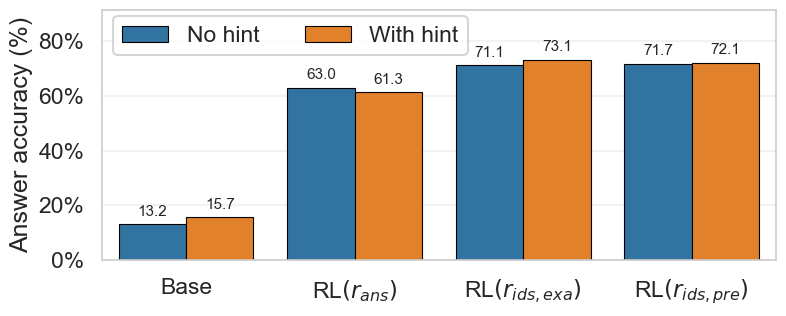

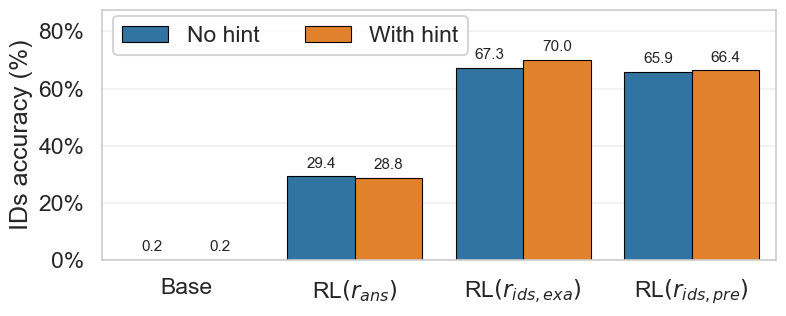

In [28]:
paths = [
    'passk_out/activity_Qwen2.5-7B-Instruct_predictions_passk.jsonl', 
    'passk_out/activity_activity_answer_qwen7b_predictions_passk.jsonl',
    'passk_out/activity_activity_id_exact_predictions_passk.jsonl',
    'passk_out/activity_activity_id_qwen7b_predictions_passk.jsonl'
]

# You can pass a LIST (aligned by order) ...
labels = [
    "Base",
    "RL$(r_{ans})$",
    "RL$(r_{ids,exa})$",
    "RL$(r_{ids,pre})$",
]


outs, summary = plot_hint_vs_nohint_bars(
    jsonl_paths=paths,
    model_labels=labels,
    hint_legend=("No hint", "With hint"),  # customize legend text
    out_dir="figs",
    dpi=300,
    save_pdf=True,
    prefix='activity'
)


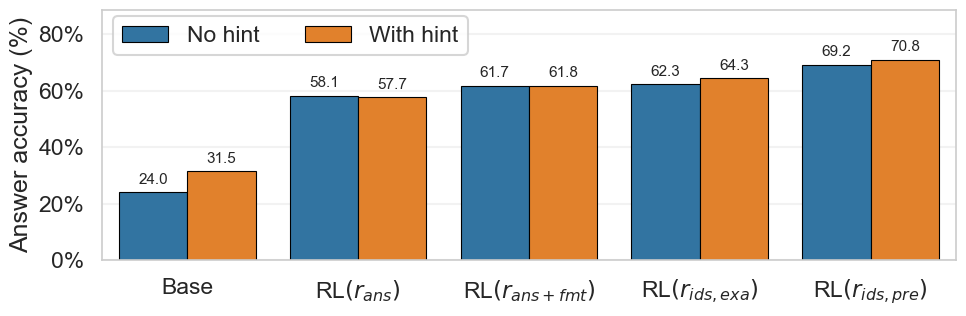

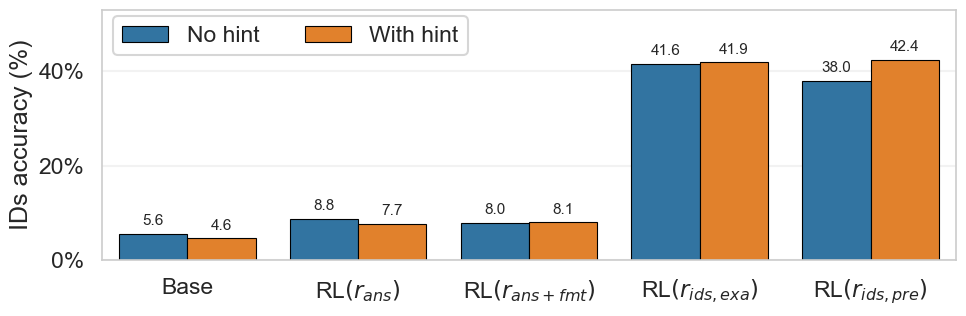

In [30]:
paths = [
    'passk_out/lis_Qwen2.5-7B-Instruct_predictions_passk.jsonl', 
    'passk_out/lis_lis_answer_qwen7b_predictions_passk.jsonl',
    'passk_out/lis_lis_answer_reason_predictions_passk.jsonl',
    'passk_out/lis_lis_id_exact_qwen7b_predictions_passk.jsonl',
    'passk_out/lis_lis_id_qwen7b_predictions_passk.jsonl'
]

# You can pass a LIST (aligned by order) ...
labels = [
    "Base",
    "RL$(r_{ans})$",
    "RL$(r_{ans+fmt})$",
    "RL$(r_{ids,exa})$",
    "RL$(r_{ids,pre})$",
]


outs, summary = plot_hint_vs_nohint_bars(
    jsonl_paths=paths,
    model_labels=labels,
    hint_legend=("No hint", "With hint"),  # customize legend text
    out_dir="figs",
    dpi=300,
    save_pdf=True,
    prefix='lis'
)
